# Liability-driven allocation: protect the surplus

[Chapter](README.md) · [Allocation ideas](../../README.md)

A pension or endowment with dated spending obligations has an allocation objective that asset-only volatility misses: protect the value of assets **relative to liabilities**. This constructed example matches liability present value and dollar duration with two zero-coupon bonds. It removes the first-order effect of a small parallel rate move, but leaves a measurable curve-shape mismatch and mismatched payment dates.

All amounts, dates and rates below are constructed. The experiment is an instantaneous revaluation of frozen cash flows, not a historical return strategy, a funding forecast or a complete pension valuation.

## Define the obligation and valuation convention

The valuation date is 19 September 2026. Liabilities pay 60 units on 19 September 2030 and 70 units on 19 September 2033. Available hedge zeros mature on 19 September 2028 and 19 September 2036. Times use actual calendar days divided by 365; payments are not business-day adjusted. The base curve is flat at 4%, continuously compounded. Assets and liabilities use the same discount curve, with no credit risk, tax, costs or optionality.

For payment amounts $C_i$ at times $t_i$, $P=\sum_i C_i e^{-y_i t_i}$ and dollar duration $DD=\sum_i t_i C_i e^{-y_i t_i}$. Under a parallel additive zero-rate shift $\delta$, $dP/d\delta=-DD$. Dollar convexity is $DC=\sum_i t_i^2 C_i e^{-y_i t_i}$.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "research/factors_liabilities.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from research.factors_liabilities import (
    factor_decomposition, exposure_target_allocation,
    cashflow_measures, match_liability_zeros,
)
plt.rcParams.update({"figure.figsize": (10, 4), "font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.18,
                     "axes.axisbelow": True})
BLUE, GOLD, ORANGE, GREY = "#245B83", "#B78324", "#BB623B", "#69747E"
valuation = pd.Timestamp("2026-09-19")
liability_dates = pd.to_datetime(["2030-09-19", "2033-09-19"])
asset_dates = pd.to_datetime(["2028-09-19", "2036-09-19"])
liability_times = ((liability_dates - valuation).days / 365).to_numpy()
asset_times = ((asset_dates - valuation).days / 365).to_numpy()
liability_cashflows = np.array([60., 70.])
base_rate = .04
liability = cashflow_measures(liability_times, liability_cashflows, base_rate)
capital = liability["pv"]  # Fully funded initial capital; no hidden borrowing.
display(pd.DataFrame({"Payment date": liability_dates.date, "Amount (units)": liability_cashflows,
                      "Time (ACT/365F years)": liability_times,
                      "Present value (units)": liability_cashflows*np.exp(-base_rate*liability_times)}).round(4))
print(f"Required initial capital: {capital:.4f} units; liability duration: {liability['duration']:.4f} years")


,Payment date,Amount (units),Time (ACT/365F years),Present value (units)
0,2030-09-19,60.0,4.0027,51.1230
1,2033-09-19,70.0,7.0055,52.8933


Required initial capital: 104.0163 units; liability duration: 5.5297 years


## Fund and size the hedge

Let $x_1,x_2$ denote present-value dollars allocated to the two zeros. Solve $x_1+x_2=L_0$ and $t_1x_1+t_2x_2=DD_L$. These constraints match both the budget and the first derivative of surplus $S=A-L$. The zero's face value is $x_i e^{yt_i}$, not $x_i$ itself. A nonnegative solution exists only when the two maturities bracket the liability's PV-weighted time. Capital must cover $L_0$; otherwise this fully funded design rejects the allocation.

In [2]:
hedge = match_liability_zeros(liability_times, liability_cashflows, asset_times, base_rate, capital)
face = hedge["face_values"]
asset = cashflow_measures(asset_times, face, base_rate)
display(pd.DataFrame({"Maturity": asset_dates.date, "Capital allocation (units)": hedge["market_values"],
                      "Portfolio weight (%)": 100*hedge["market_values"]/capital,
                      "Bond face value (units)": face}).round(4))
display(pd.DataFrame({"Assets": asset, "Liabilities": liability}).round(5))


,Maturity,Capital allocation (units),Portfolio weight (%),Bond face value (units)
0,2028-09-19,58.1905,55.9437,63.0439
1,2036-09-19,45.8258,44.0563,68.3865


,Assets,Liabilities
pv,104.01629,104.01629
duration,5.52966,5.52966
dollar_duration,575.17486,575.17486
dollar_convexity,4823.51381,3414.91855


Matching dollar duration is the funded-surplus condition. Equal percentage duration alone would leave a first-order mismatch if asset and liability present values differed. Here they are deliberately equal. The hedge is a dedicated liability portfolio: it leaves no separate capital for a growth sleeve. With additional capital, the function reports an explicit cash balance.

## Distinguish duration matching from payment matching

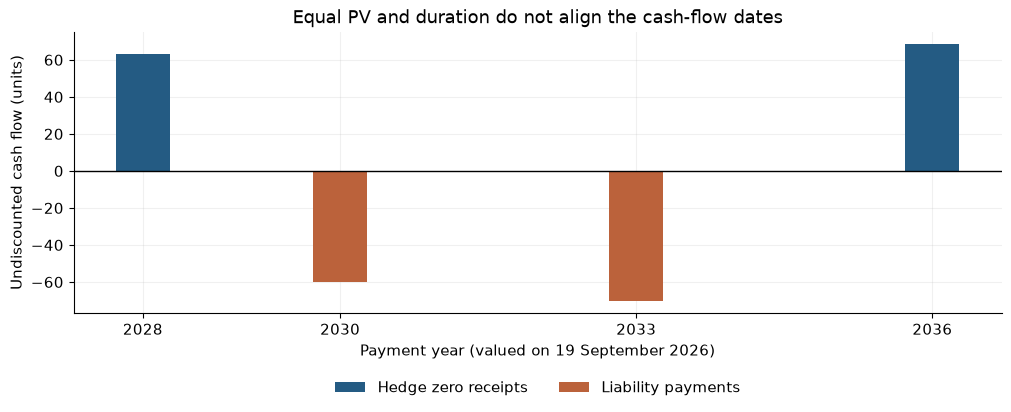

In [3]:
fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")
ax.bar(asset_times, face, width=.55, color=BLUE, label="Hedge zero receipts")
ax.bar(liability_times, -liability_cashflows, width=.55, color=ORANGE, label="Liability payments")
ax.axhline(0, color="black", linewidth=1)
all_dates = sorted(zip(np.r_[asset_times, liability_times], [*asset_dates.year, *liability_dates.year]))
ax.set(xticks=[t for t, _ in all_dates], xticklabels=[str(y) for _, y in all_dates],
       xlabel="Payment year (valued on 19 September 2026)", ylabel="Undiscounted cash flow (units)",
       title="Equal PV and duration do not align the cash-flow dates")
ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(.5, -.19))
plt.show()


The 2028 receipt must be reinvested or reserved before liability payments, while the 2036 zero would need to be sold before maturity. This example does not assume that these future funding transactions are costless or feasible. Buying zeros with exactly the liability dates and face amounts would instead match these deterministic payments, if those instruments existed on the same curve.

## Revalue frozen holdings under parallel shocks

For small shifts, $\Delta S\approx-(DD_A-DD_L)\delta+\tfrac12(DC_A-DC_L)\delta^2$. The linear term is zero by construction. The barbell has greater dollar convexity than these liabilities, leaving a positive local quadratic term; that is a property of this cash-flow geometry, not a general guarantee for duration-matched portfolios.

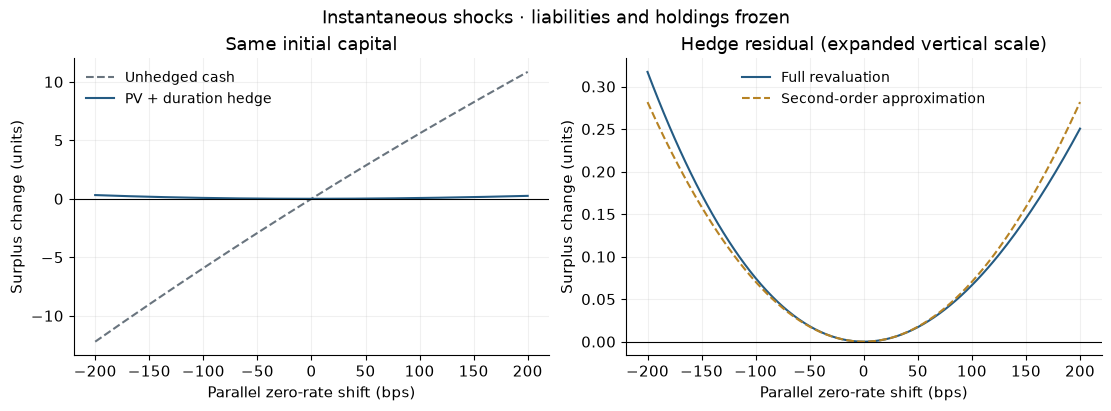

In [4]:
def frozen_surplus(asset_rates, liability_rates):
    a = np.sum(face*np.exp(-np.asarray(asset_rates)*asset_times))
    l = np.sum(liability_cashflows*np.exp(-np.asarray(liability_rates)*liability_times))
    return float(a - l)
shifts = np.linspace(-.02, .02, 161)
exact = np.array([frozen_surplus(base_rate+d, base_rate+d) for d in shifts])
cash_surplus = np.array([capital - np.sum(liability_cashflows*np.exp(-(base_rate+d)*liability_times)) for d in shifts])
quadratic = .5*(asset["dollar_convexity"]-liability["dollar_convexity"])*shifts**2
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
axes[0].plot(1e4*shifts, cash_surplus, color=GREY, label="Unhedged cash", linestyle="--")
axes[0].plot(1e4*shifts, exact, color=BLUE, label="PV + duration hedge")
axes[1].plot(1e4*shifts, exact, color=BLUE, label="Full revaluation")
axes[1].plot(1e4*shifts, quadratic, color=GOLD, linestyle="--", label="Second-order approximation")
for ax, title in zip(axes, ["Same initial capital", "Hedge residual (expanded vertical scale)"]):
    ax.axhline(0, color="black", linewidth=.8)
    ax.set(xlabel="Parallel zero-rate shift (bps)", ylabel="Surplus change (units)", title=title)
    ax.legend(frameon=False, fontsize=10)
fig.suptitle("Instantaneous shocks · liabilities and holdings frozen")
plt.show()


The hedge makes surplus much less sensitive to a parallel shift than holding the same initial capital as cash. The expanded panel makes the remaining curvature visible. The second-order line increasingly differs from exact revaluation as shock size grows. No passage of time, coupon reinvestment, future rebalancing or realized return is included.

## Stress curve shape and compare exact cash-flow matching

A steepener applies a slope of 12.5 bps per year around year six: approximately −50 bps at the short hedge zero and +50 bps at the long one. Its reverse is a flattener. A localized +100 bps triangular bump is centered at the 2033 liability payment, with a one-year half-width. These deterministic shocks expose risks that a single parallel-duration constraint does not span.

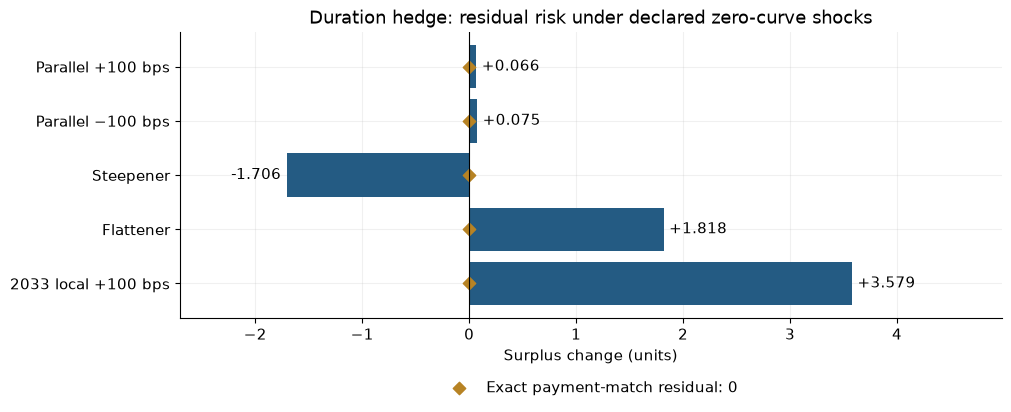

In [5]:
shapes = {
    "Parallel +100 bps": lambda t: np.full_like(t, .01),
    "Parallel −100 bps": lambda t: np.full_like(t, -.01),
    "Steepener": lambda t: .00125*(t-6),
    "Flattener": lambda t: -.00125*(t-6),
    "2033 local +100 bps": lambda t: .01*np.maximum(1-np.abs(t-liability_times[1]), 0),
}
scenario_values = [frozen_surplus(base_rate+s(asset_times), base_rate+s(liability_times)) for s in shapes.values()]
fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")
y = np.arange(len(shapes))
bars = ax.barh(y, scenario_values, color=BLUE)
ax.bar_label(bars, labels=[f"{v:+.3f}" for v in scenario_values], padding=4)
ax.scatter(np.zeros(len(y)), y, color=GOLD, marker="D", s=40, label="Exact payment-match residual: 0")
ax.axvline(0, color="black", linewidth=.8)
ax.set(yticks=y, yticklabels=list(shapes), xlabel="Surplus change (units)",
       title="Duration hedge: residual risk under declared zero-curve shocks")
ax.set_xlim(min(scenario_values)-1.0, max(scenario_values)+1.4)
ax.invert_yaxis()
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(.5, -.17))
plt.show()


The steepener produces a surplus loss despite the exact base-date duration match. Exact payment matching has zero residual in these rate-only scenarios because asset and liability cash flows coincide at every date and use identical discount factors. Neither construction covers changes to promised payments, longevity, inflation linkage, credit spreads, liquidity needs or an inconsistent liability discount convention.

## Independently verify the hedge and reject impossible requests

In [6]:
# Independent 2x2 linear system solves for PV allocations directly.
reference = np.linalg.solve(np.vstack([np.ones(2), asset_times]),
                            [sum(liability_cashflows*np.exp(-base_rate*liability_times)),
                             sum(liability_times*liability_cashflows*np.exp(-base_rate*liability_times))])
np.testing.assert_allclose(hedge["market_values"], reference, atol=1e-11)
assert abs(frozen_surplus(base_rate, base_rate)) < 1e-11
bump = 1e-5
slope = (frozen_surplus(base_rate+bump, base_rate+bump)-frozen_surplus(base_rate-bump, base_rate-bump))/(2*bump)
assert abs(slope) < 1e-5
for shape in shapes.values():
    matched_receipts = sum(liability_cashflows*np.exp(-(base_rate+shape(liability_times))*liability_times))
    liability_value = cashflow_measures(liability_times, liability_cashflows, base_rate+shape(liability_times))["pv"]
    assert abs(matched_receipts-liability_value) < 1e-11
for label, times, available in [("Underfunded", asset_times, .9*capital),
                                 ("Maturities do not span liability duration", np.array([1., 2.]), capital)]:
    try:
        match_liability_zeros(liability_times, liability_cashflows, times, base_rate, available)
    except ValueError as exc:
        print(f"{label}: rejected ({exc})")
    else:
        raise AssertionError("An infeasible hedge was accepted")
print("Independent funding, cash-flow, derivative and scenario checks passed.")


Underfunded: rejected (Insufficient capital for the fully funded liability hedge)
Maturities do not span liability duration: rejected (Liability duration is outside the long-only maturity range)
Independent funding, cash-flow, derivative and scenario checks passed.


## Treat liabilities as part of the allocation design

The hedging objective comes from an obligation, not a search for a strong historical Sharpe ratio. That reduces one source of return overfitting, but uncertainty moves into the liability schedule, curve, inflation assumptions and available instruments. A full study would compare key-rate matching and cash-flow matching with the same funding budget, then model liquidity and payment uncertainty across time. The zero-bond example provides a bounded first step, not a complete ALM solution.

[Sharpe (2001)](https://web.stanford.edu/~wfsharpe/art/q2001/q2001.htm) explains why pension allocation should include liabilities in the economic risk objective. [Akhtari (2026), Society of Actuaries](https://www.soa.org/communities/investment-and-risk-management/newsletter-articles/2026/january/2026-01-ir-akhtari/) discusses limitations of aggregate duration and the role of cash-flow and liquidity stress tests. The cash flows, formulas, calculations and scenarios in this notebook are original. See also [factor exposures](../15-factor-risk-allocation/README.md).